# Traffic Death Analysis

In this exercise, we will be analyzing the effect of alcohol taxes on traffic death in the United States.  The data set used in this exercise, `fatalities.csv`, is a state-year panel dataset (meaning it includes data on multiple states, and the data includes several years of data for each state. The data contains 336 observations on 34 variables. The variables used in the exercise are defined as follows:

`state`: factor variable indicating states

`year`: factor variable indicating years

`beertax`: numeric variable, Tax on the case of beer

In these exercises, we'll be looking at how beer taxes (which are believed to reduce alcohol consumption, potentially reducing drunk driving deaths) impact car accident fatality rates. 

More specifically, though, we'll be approaching our estimation of the impact of beer taxes in a few different ways in an effort to give you more of an intuitive sense of what happens when you add fixed effects to a regression. 



## Gradescope Autograding

Please follow [all standard guidance](https://www.practicaldatascience.org/ids720_specific/autograder_guidelines.html) for submitting this assignment to the Gradescope autograder, including storing your solutions in a dictionary called `results` and ensuring your notebook runs from the start to completion without any errors.

For this assignment, please name your file `exercise_panel.ipynb` before uploading.

You can check that you have answers for all questions in your `results` dictionary with this code:

```python
assert set(results.keys()) == {
    "ex1_num_states",
    "ex1_num_years",
    "ex2_avg_fatality_rate",
    "ex4_pooled_beta",
    "ex5_statefe_beta",
    "ex6_demeaned_beta",
    "ex7_panelols_beta",
    "ex7_panelols_se",
    "ex8_twfe_beta",
}
```

### Submission Limits

Please remember that you are **only allowed THREE submissions to the autograder.** Your last submission (if you submit 3 or fewer times), or your third submission (if you submit more than 3 times) will determine your grade Submissions that error out will **not** count against this total.


## Exercise 1

Download and load the data from [this link](https://github.com/nickeubank/MIDS_Data/blob/master/UDS_arrest_data.csv), or by going to [http://www.github.com/nickeubank/MIDS_Data/](http://www.github.com/nickeubank/MIDS_Data/) and downloading the `us_driving_fatalities.csv` dataset. 

How many states does this dataset contain? What's the time frame of this dataset? (From which year to which year). And what constitutes a single observation (i.e. what is the unit of analysis for each row of the data?)

Store the number of states in `"ex1_num_states"` and number of years in `"ex1_num_years"`

In [ ]:
import pandas as pd

pd.set_option("mode.copy_on_write", True)

url = "https://github.com/nickeubank/MIDS_Data/raw/refs/heads/master/us_driving_fatalities.csv"

df = pd.read_csv(url)

df.head()

,Unnamed: 0,state,year,spirits,unemp,income,emppop,beertax,baptist,mormon,...,nfatal2124,afatal,pop,pop1517,pop1820,pop2124,milestot,unempus,emppopus,gsp
0,1,al,1982,1.37,14.4,10544.152344,50.692039,1.539379,30.355700,0.32829,...,32,309.437988,3942002.25,208999.593750,221553.43750,290000.06250,28516.0,9.7,57.799999,-0.022125
1,2,al,1983,1.36,13.7,10732.797852,52.147030,1.788991,30.333599,0.34341,...,35,341.834015,3960008.00,202000.078125,219125.46875,290000.15625,31032.0,9.6,57.900002,0.046558
2,3,al,1984,1.32,11.1,11108.791016,54.168087,1.714286,30.311501,0.35924,...,34,304.872009,3988991.75,196999.968750,216724.09375,288000.15625,32961.0,7.5,59.500004,0.062798
3,4,al,1985,1.28,8.9,11332.626953,55.271137,1.652542,30.289499,0.37579,...,45,276.742004,4021007.75,194999.734375,214349.03125,284000.31250,35091.0,7.2,60.100002,0.027490
4,5,al,1986,1.23,9.8,11661.506836,56.514496,1.609907,30.267401,0.39311,...,29,360.716003,4049993.75,203999.890625,212000.00000,263000.28125,36259.0,7.0,60.700001,0.032143


In [ ]:
results = {}

results["ex1_num_states"] = df["state"].nunique()

results["ex1_num_years"] = df["year"].nunique()

year_min = df["year"].min()
year_max = df["year"].max()

print(f"The number of states: {results['ex1_num_states']}")
print(f"The number of years: {results['ex1_num_years']}")
print(f"The time frame of this dataset is from {year_min} to {year_max}")

The number of states: 48
The number of years: 7
The time frame of this dataset is from 1982 to 1988


A single observation represents one state in one specific year.

## Exercise 2

We use the fatality rate per 10,000 as the dependent variable, which you can compute using total fatalities(`fatal`) and population (`pop`). Note that because `pop` is often the name of a method in Python, you may have to navigate around some issues.

Please store the average fatality rate per 10_000 in for the dataset in `"ex2_avg_fatality_rate"`.

In [7]:
df["fat_rate"] = (df["fatal"] / df["pop"]) * 10000

results["ex2_avg_fatality_rate"] = df["fat_rate"].mean()

print(f"The average fatality rate per 10,000 is: {results['ex2_avg_fatality_rate']}")

The average fatality rate per 10,000 is: 2.040443784423569


## Exercise 3

Draw a scatter plot using `beertax` as the x-axis, and `fat_rate` as the y-axis. Draw a fitted line showing the correlation between these two variables

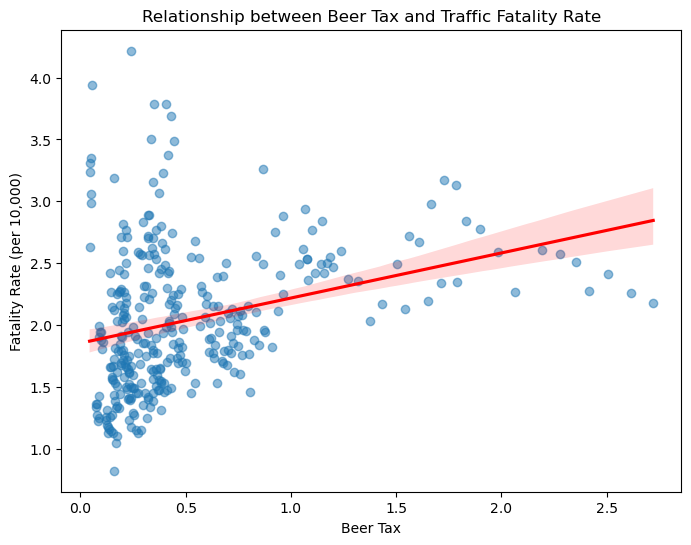

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the figure for better readability
plt.figure(figsize=(8, 6))

sns.regplot(
    x="beertax",
    y="fat_rate",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)

plt.title("Relationship between Beer Tax and Traffic Fatality Rate")
plt.xlabel("Beer Tax")
plt.ylabel("Fatality Rate (per 10,000)")

plt.show()

## Exercise 4

Fit a simple OLS regression. This is sometimes called a "pooled" regression because we're "pooling" observations from different years into a single regression with no consideration of the time structure. 

Store the coefficient on beer tax in `"ex4_pooled_beta"`.

What do your results imply about the relationship between Beer Taxes and fatalities?

\begin{align*}
FatalityRate_i = \beta_0 + \beta_1 \times BeerTax_i
\end{align*}

In [ ]:
import statsmodels.formula.api as smf

pooled_model = smf.ols("fat_rate ~ beertax", data=df).fit()

results["ex4_pooled_beta"] = pooled_model.params["beertax"]

print(f"The pooled OLS coefficient for beer tax is: {results['ex4_pooled_beta']}")

print(pooled_model.summary())

The pooled OLS coefficient for beer tax is: 0.3646054403677417
                            OLS Regression Results                            
Dep. Variable:               fat_rate   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     34.39
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.08e-08
Time:                        17:46:20   Log-Likelihood:                -271.04
No. Observations:                 336   AIC:                             546.1
Df Residuals:                     334   BIC:                             553.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

- A positive coefficient implies that higher beer taxes are associated with higher traffic fatality rates. 

- Because this is a pooled regression, it ignores the time structure and state-level differences, meaning this result is heavily impacted by omitted variable bias. 

- It does not mean that raising taxes causes more deaths; rather, it suggests that states with higher fatality rates might be the ones implementing higher beer taxes, or there are other unobserved cultural or economic factors driving both variables.

## Exercise 5

Now estimate your model again, this time adding state fixed effects (using the `C()` notation and your normal linear model machinery). What does this result imply about the relationship between beer taxes and fatalities?

Store the coefficient under `"ex5_statefe_beta"`



In [12]:
pooled_model2 = smf.ols("fat_rate ~ beertax + C(state)", data=df).fit()

results["ex5_statefe_beta"] = pooled_model2.params["beertax"]

print(f"The State FE coefficient for beer tax is: {results['ex5_statefe_beta']}")

The State FE coefficient for beer tax is: -0.6558737221504805


- The coefficient for beertax turns negative. 

- By adding C(state), we are giving each state its own intercept (a fixed effect). This controls for all the unobserved, time-invariant differences between states (like local culture, average driving distances, or baseline religious attitudes toward alcohol). 

- Because of this, the negative coefficient now implies that within a given state, an increase in the beer tax is associated with a decrease in the traffic fatality rate.

## Exercise 6

Explain whey your results in Exercises 4 (without fixed effects) and Exercise 5 (with state fixed effects) look so different. What does this imply about states with high beer taxes?

- Why they look so different: 

    - The pooled regression in Exercise 4 suffers from Omitted Variable Bias. 
    
    - It lumps all states together, ignoring underlying, time-invariant differences between them (like state culture, road infrastructure, or baseline alcohol consumption). 
    
    - Exercise 5 adds state fixed effects, which acts like a unique baseline for every single state. This allows the model to look at within-state changes over time (i.e., what happens to fatalities when a specific state raises its tax).

- What this implies about states with high beer taxes: 

    - The positive coefficient in Exercise 4 implies that states with high beer taxes also tend to be the states with historically high fatality rates. 
    
    - This makes logical sense: states with severe drunk driving problems are probably the ones most motivated to pass high beer taxes to try and solve the problem.

## Fixed Effects by Demeaning

Rather than just add indicator variables, we'll now use a different strategy for estimating fixed effects called an "entity-demeaning." This method is more computationally efficient, and can also help you understand how fixed effects work. 

Let's begin by assuming we want to estimate the following fixed-effect model:

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + \Psi Z_i + \epsilon_{it} \tag{1}
\end{align}

Where $FatalityRate_{it}$ is the fatality rate of state $i$ in year $t$, $\beta BeerTax_{it}$ is the beer tax of state $i$ in year $t$. $Z_i$ is a state fixed effect.

Rather than adding indicator variables, however, we'll use entity-demean as follows: 

First, we take the average on both sides of the regression. Here $n$ is the number of periods. 

\begin{align*}
\frac{1}{n} \sum_{i=1}^n FatalityRate_{it} =&  \,\alpha+ \beta_1 \frac{1}{n} \sum_{i=1}^n BeerTax_{it} + \Psi \frac{1}{n} \sum_{i=1}^n Z_i + \frac{1}{n} \sum_{i=1}^n \epsilon_{it} \\
\overline{FatalityRate}_i =& \,\alpha+ \beta_1 \overline{BeerTax}_i + \Psi  Z_i + \overline{\epsilon}_i.  \tag{2}
\end{align*}

Substracting the  from the main equation yields:

\begin{align*}
FatalityRate_{it} - \overline{FatalityRate}_i =& \, \beta_1(BeerTax_{it}-\overline{BeerTax}_i) + \Psi (Z_i - Z_i) + (\epsilon_{it} - \overline{\epsilon}_i)  \\
\overset{\sim}{FatalityRate}_{it} =& \, \beta_1 \overset{\sim}{BeerTax}_{it} + \overset{\sim}{\epsilon}_{it}  \tag{3}
\end{align*}

Where the $\sim$ means values have been demeaned by group. 

By taking the difference between the value of each observation (state-year) and the mean value of the entity (state) over n periods, we analyze how the within-state variation of beer tax affects that of the fatality rate. Moreover, by doing so we no longer need to estimate the fixed effects of $Z_i$, saving computing power if we are working on a dataset with a large number of fixed effects.

## Exercise 6

Implement the above entity-demeaned approach to estimate the fixed-effects model by hand (use basic functions, not full tools like `PanelOLS` or `C()` notation in `python`).

Compare your answer to the answer you got in Ex 5.

In [ ]:
# Calculate the demeaned fatality rate
df["fat_rate_demeaned"] = df["fat_rate"] - df.groupby("state")["fat_rate"].transform(
    "mean"
)

# Calculate the demeaned beer tax
df["beertax_demeaned"] = df["beertax"] - df.groupby("state")["beertax"].transform(
    "mean"
)

# Fit the model
demeaned_model = smf.ols("fat_rate_demeaned ~ beertax_demeaned - 1", data=df).fit()

results["ex6_demeaned_beta"] = demeaned_model.params["beertax_demeaned"]

print(f"The demeaned coefficient for beer tax is: {results['ex6_demeaned_beta']}")

The demeaned coefficient for beer tax is: -0.6558737221504345


The coefficient that is extremely close to the -0.6558 I got in Exercise 5.

## Exercise 7 

Fit the model with state fixed-effect using `PanelOLS` / `lfe`. Note that PanelOLS automatically clusters standard errors when you add `EntityEffects` (unlike statsmodel's OLS function).

Compare it to your by-hand output. Store your coefficient in `"ex7_panelols_beta"` and your standard error `"ex7_panelols_se"`.

Interpret the result, including standard errors.

In [ ]:
from linearmodels.panel import PanelOLS

df_panel = df.set_index(["state", "year"])

panel_model = PanelOLS.from_formula(
    "fat_rate ~ 1 + beertax + EntityEffects", data=df_panel
)
panel_results = panel_model.fit()

results["ex7_panelols_beta"] = panel_results.params["beertax"]
results["ex7_panelols_se"] = panel_results.std_errors["beertax"]

print(f"PanelOLS Coefficient: {results['ex7_panelols_beta']}")
print(f"PanelOLS Standard Error: {results['ex7_panelols_se']}")

PanelOLS Coefficient: -0.6558737221504365
PanelOLS Standard Error: 0.18784999357616133


- The Coefficient: 

    - The coefficient is identical to what I found in Exercises 5 and 6 (around -0.6559). 
    
    - The interpretation remains the same: an increase in a state's beer tax is associated with a decrease in that state's traffic fatality rate.

- The Standard Errors: 

    - The standard error of 0.1878 yields a t-statistic of approximately -3.49, meaning the negative effect of beer taxes on fatality rates is statistically significant. 
    
    - Furthermore, because PanelOLS automatically clustered these standard errors by state, this estimate reliably accounts for within-state correlation over time.

## Exercise 8

Now (using `PanelOLS`) estimate a fixed effects model using the following specification. Add fixed effects for **both** the state and the year, as well as the other covariates you think are important $X_{it}$). 

(Note: you may want to make sure `PanelOLS` adds an intercept to aid in interpretation of controls if you include categorical variables. If you use `PanelOLS.from_formula()`, just put a `1+` in after the `~`, or add a column of 1s to your X matrix if you're working with numpy arrays.)

Explain (a) the type of phenomenon we control for by adding `year` fixed effects, and (b) your choice of covariates. 

Put your beer tax coefficient in `"ex8_twfe_beta"`.

Interpret the result.

\begin{align}
FatalityRate_{it} = \alpha + \beta BeerTax_{it} + X_{it} + State_i + Year_t + \epsilon_{it}
\end{align}

In [15]:
twfe_formula = "fat_rate ~ 1 + beertax + EntityEffects + TimeEffects"

twfe_model = PanelOLS.from_formula(twfe_formula, data=df_panel)
twfe_results = twfe_model.fit()

results["ex8_twfe_beta"] = twfe_results.params["beertax"]

print(f"TWFE Coefficient: {results['ex8_twfe_beta']}")
print(twfe_results.summary)

TWFE Coefficient: -0.6399799857068744
                          PanelOLS Estimation Summary                           
Dep. Variable:               fat_rate   R-squared:                        0.0361
Estimator:                   PanelOLS   R-squared (Between):             -0.6875
No. Observations:                 336   R-squared (Within):               0.0407
Date:                Sun, Mar 01 2026   R-squared (Overall):             -0.6154
Time:                        18:29:14   Log-likelihood                    115.04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      10.513
Entities:                          48   P-value                           0.0013
Avg Obs:                       7.0000   Distribution:                   F(1,281)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):          

- The Coefficient: 

    - The -0.6400 coefficient means that after controlling for unobserved, time-invariant state characteristics and national trends that affect all states uniformly over time, a 1-dollar (or 1-unit) increase in the beer tax is associated with a decrease of 0.64 deaths per 10,000 people.

- Statistical Significance: 

    - The p-value is 0.0013 (which is well below 0.05) and the t-statistic is -3.2424. This means my result remains highly statistically significant even after aggressively controlling for both state and year fixed effects.

In [16]:
assert set(results.keys()) == {
    "ex1_num_states",
    "ex1_num_years",
    "ex2_avg_fatality_rate",
    "ex4_pooled_beta",
    "ex5_statefe_beta",
    "ex6_demeaned_beta",
    "ex7_panelols_beta",
    "ex7_panelols_se",
    "ex8_twfe_beta",
}